# COGS118A Final Project 

## 1) Imports and Paths

In [1]:
from pathlib import Path
import json
import zipfile
import numpy as np
import pandas as pd

from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

import matplotlib.pyplot as plt

# ---- Set these paths ----
DATA_DIR = Path(".").resolve()          # folder containing the zip files
OUT_DIR  = Path("./outputs").resolve()  # where results will be saved
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR, OUT_DIR


(WindowsPath('C:/Users/james/Desktop/Cogs118A'),
 WindowsPath('C:/Users/james/Desktop/Cogs118A/outputs'))

## 2) Helpers

In [2]:
def extract_zip(zip_path: Path, out_dir: Path) -> Path:
    out_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(out_dir)
    return out_dir

def load_heart(data_dir: Path) -> tuple[pd.DataFrame, pd.Series]:
    """UCI Heart Disease (Cleveland). Binary label: y=1 if num>0 else 0."""
    zip_path = data_dir / "heart+disease.zip"
    extract_dir = data_dir / "_heart_extracted"
    extract_zip(zip_path, extract_dir)

    path = extract_dir / "processed.cleveland.data"
    cols = [
        "age","sex","cp","trestbps","chol","fbs","restecg","thalach","exang","oldpeak",
        "slope","ca","thal","num"
    ]
    df = pd.read_csv(path, header=None, names=cols)
    df = df.replace("?", np.nan)

    for c in cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    y = (df["num"] > 0).astype(int)
    X = df.drop(columns=["num"])
    return X, y

def load_wine(data_dir: Path, threshold: int = 7) -> tuple[pd.DataFrame, pd.Series]:
    """UCI Wine Quality (red+white combined). Binary label: y=1 if quality>=threshold else 0."""
    zip_path = data_dir / "wine+quality.zip"
    extract_dir = data_dir / "_wine_extracted"
    extract_zip(zip_path, extract_dir)

    red = pd.read_csv(extract_dir / "winequality-red.csv", sep=";")
    white = pd.read_csv(extract_dir / "winequality-white.csv", sep=";")
    red["type"] = "red"
    white["type"] = "white"
    df = pd.concat([red, white], ignore_index=True)

    y = (df["quality"] >= threshold).astype(int)
    X = df.drop(columns=["quality"])
    return X, y

def load_adult(data_dir: Path) -> tuple[pd.DataFrame, pd.Series]:
    """UCI Adult dataset. Binary label: y=1 if income>50K else 0."""
    zip_path = data_dir / "adult.zip"
    extract_dir = data_dir / "_adult_extracted"
    extract_zip(zip_path, extract_dir)

    cols = [
        "age","workclass","fnlwgt","education","education-num","marital-status",
        "occupation","relationship","race","sex","capital-gain","capital-loss",
        "hours-per-week","native-country","income"
    ]

    train = pd.read_csv(
        extract_dir / "adult.data",
        header=None, names=cols,
        na_values=" ?", skipinitialspace=True
    )

    test = pd.read_csv(
        extract_dir / "adult.test",
        header=None, names=cols,
        na_values=" ?", skipinitialspace=True,
        skiprows=1
    )
   
    test["income"] = test["income"].astype(str).str.replace(".", "", regex=False)

    df = pd.concat([train, test], ignore_index=True)
    y = (df["income"].astype(str).str.strip() == ">50K").astype(int)
    X = df.drop(columns=["income"])
    return X, y

def stratified_sample(X: pd.DataFrame, y: pd.Series, n: int, seed: int = 0):
    """Optional: stratified subsample for faster debugging."""
    if n is None or len(y) <= n:
        return X, y
    rng = np.random.RandomState(seed)
    idx0 = np.where(y.values == 0)[0]
    idx1 = np.where(y.values == 1)[0]
    n1 = int(round(n * y.mean()))
    n0 = n - n1
    s0 = rng.choice(idx0, size=min(n0, len(idx0)), replace=False)
    s1 = rng.choice(idx1, size=min(n1, len(idx1)), replace=False)
    idx = np.concatenate([s0, s1])
    rng.shuffle(idx)
    return X.iloc[idx].reset_index(drop=True), y.iloc[idx].reset_index(drop=True)


## 3) Load datasets

In [3]:
WINE_THRESHOLD = 7   

Xh, yh = load_heart(DATA_DIR)
Xw, yw = load_wine(DATA_DIR, threshold=WINE_THRESHOLD)
Xa, ya = load_adult(DATA_DIR)

SAMPLE_ADULT = None  
if SAMPLE_ADULT is not None:
    Xa, ya = stratified_sample(Xa, ya, n=SAMPLE_ADULT, seed=42)

datasets = {
    "HeartDisease": (Xh, yh),
    "WineQuality":  (Xw, yw),
    "AdultIncome":  (Xa, ya),
}

summary = []
for name, (X, y) in datasets.items():
    summary.append({
        "dataset": name,
        "n_samples": len(y),
        "n_features": X.shape[1],
        "positive_rate": float(y.mean())
    })
pd.DataFrame(summary)


,dataset,n_samples,n_features,positive_rate
0,HeartDisease,303,13,0.458746
1,WineQuality,6497,12,0.196552
2,AdultIncome,48842,14,0.239282


## 4) Preprocessing and Models

In [4]:
def build_preprocess(X: pd.DataFrame, scale_numeric: bool) -> ColumnTransformer:
    cat_cols = [c for c in X.columns if X[c].dtype == "object"]
    num_cols = [c for c in X.columns if c not in cat_cols]

    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        
        num_steps.append(("scaler", StandardScaler(with_mean=False)))
    num_pipe = Pipeline(num_steps)

    transformers = [("num", num_pipe, num_cols)]
    if len(cat_cols) > 0:
        cat_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ])
        transformers.append(("cat", cat_pipe, cat_cols))

    return ColumnTransformer(transformers)

def get_models():
    models = {}

    # Logistic Regression 
    lr = LogisticRegression(max_iter=5000, solver="saga", penalty="l2", n_jobs=-1)
    models["LogReg"] = (lr, {"clf__C": [0.01, 0.1, 1, 10]}, True)

    # Linear SVM
    svm = LinearSVC(max_iter=20000)
    models["LinSVM"] = (svm, {"clf__C": [0.01, 0.1, 1, 10]}, True)

    # Random Forest
    rf = RandomForestClassifier(random_state=0, n_jobs=-1)
    models["RandForest"] = (
        rf,
        {
            "clf__n_estimators": [300],
            "clf__max_depth": [None, 10, 20],
            "clf__max_features": ["sqrt", "log2"],
            "clf__min_samples_leaf": [1, 5],
        },
        False,
    )
    return models


## 5) Core experiment loop

In [5]:
def run_experiments(
    datasets: dict,
    out_dir: Path,
    cv_folds: int = 5,
    trials: int = 3,
    train_fracs=(0.2, 0.5, 0.8),
    seed_base: int = 2025
) -> pd.DataFrame:
    out_dir.mkdir(parents=True, exist_ok=True)
    models = get_models()
    rows = []

    for dname, (X, y) in datasets.items():
        for mname, (clf, grid, scale_numeric) in models.items():
            pre = build_preprocess(X, scale_numeric=scale_numeric)
            pipe = Pipeline([("pre", pre), ("clf", clf)])

            for train_frac in train_fracs:
                test_size = 1.0 - train_frac

                for t in range(trials):
                    seed = seed_base + 1000 * ["HeartDisease","WineQuality","AdultIncome"].index(dname) \
                        + 100  * ["LogReg","LinSVM","RandForest"].index(mname) \
                            + int(train_frac * 10) + t


                    splitter = StratifiedShuffleSplit(
                        n_splits=1, test_size=test_size, random_state=seed
                    )
                    train_idx, test_idx = next(splitter.split(X, y))
                    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
                    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

                    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=seed)

                    gs = GridSearchCV(
                        pipe,
                        param_grid=grid,
                        scoring="accuracy",
                        cv=cv,
                        n_jobs=-1,
                        refit=True
                    )
                    gs.fit(X_train, y_train)

                    best = gs.best_estimator_
                    train_acc = accuracy_score(y_train, best.predict(X_train))
                    test_acc = accuracy_score(y_test, best.predict(X_test))
                    val_acc = float(gs.best_score_)

                    rows.append({
                        "dataset": dname,
                        "classifier": mname,
                        "train_frac": train_frac,
                        "trial": t + 1,
                        "n_total": len(y),
                        "train_acc": train_acc,
                        "val_acc": val_acc,
                        "test_acc": test_acc,
                        "best_params": json.dumps(gs.best_params_),
                    })

                    print(f"[DONE] {dname:12s} | {mname:10s} | train={train_frac:.1f} | trial={t+1} | "
                          f"train={train_acc:.3f} val={val_acc:.3f} test={test_acc:.3f}")

    df = pd.DataFrame(rows)
    df.to_csv(out_dir / "results_raw.csv", index=False)
    return df

def summarize(df: pd.DataFrame, out_dir: Path) -> pd.DataFrame:
    summ = (
        df.groupby(["dataset", "classifier", "train_frac"], as_index=False)
          .agg(
              train_acc_mean=("train_acc", "mean"),
              train_acc_std=("train_acc", "std"),
              val_acc_mean=("val_acc", "mean"),
              val_acc_std=("val_acc", "std"),
              test_acc_mean=("test_acc", "mean"),
              test_acc_std=("test_acc", "std"),
          )
          .sort_values(["dataset", "train_frac", "test_acc_mean"], ascending=[True, True, False])
    )
    summ.to_csv(out_dir / "results_summary.csv", index=False)
    return summ


## 6) Run the experiment

In [6]:
CV_FOLDS = 5
TRIALS = 3
TRAIN_FRACS = (0.2, 0.5, 0.8)

df_raw = run_experiments(
    datasets=datasets,
    out_dir=OUT_DIR,
    cv_folds=CV_FOLDS,
    trials=TRIALS,
    train_fracs=TRAIN_FRACS
)

df_summary = summarize(df_raw, OUT_DIR)

df_summary.head(12)


[DONE] HeartDisease | LogReg     | train=0.2 | trial=1 | train=0.867 val=0.767 test=0.827
[DONE] HeartDisease | LogReg     | train=0.2 | trial=2 | train=0.817 val=0.783 test=0.840
[DONE] HeartDisease | LogReg     | train=0.2 | trial=3 | train=0.833 val=0.800 test=0.840
[DONE] HeartDisease | LogReg     | train=0.5 | trial=1 | train=0.868 val=0.848 test=0.809
[DONE] HeartDisease | LogReg     | train=0.5 | trial=2 | train=0.848 val=0.807 test=0.849
[DONE] HeartDisease | LogReg     | train=0.5 | trial=3 | train=0.841 val=0.821 test=0.855
[DONE] HeartDisease | LogReg     | train=0.8 | trial=1 | train=0.851 val=0.847 test=0.820
[DONE] HeartDisease | LogReg     | train=0.8 | trial=2 | train=0.855 val=0.847 test=0.869
[DONE] HeartDisease | LogReg     | train=0.8 | trial=3 | train=0.855 val=0.851 test=0.820
[DONE] HeartDisease | LinSVM     | train=0.2 | trial=1 | train=0.933 val=0.900 test=0.765
[DONE] HeartDisease | LinSVM     | train=0.2 | trial=2 | train=0.900 val=0.883 test=0.815
[DONE] Hea

,dataset,classifier,train_frac,train_acc_mean,train_acc_std,val_acc_mean,val_acc_std,test_acc_mean,test_acc_std
6,AdultIncome,RandForest,0.2,0.946628,0.004742,0.856675,0.001710,0.860632,0.002306
3,AdultIncome,LogReg,0.2,0.851147,0.001648,0.849270,0.000827,0.852127,0.000288
0,AdultIncome,LinSVM,0.2,0.854047,0.002158,0.850908,0.001540,0.850463,0.000168
7,AdultIncome,RandForest,0.5,0.908849,0.029187,0.862141,0.003317,0.862768,0.002431
4,AdultIncome,LogReg,0.5,0.853787,0.001453,0.852381,0.001217,0.851972,0.001525
1,AdultIncome,LinSVM,0.5,0.854442,0.002168,0.852941,0.001238,0.851753,0.001859
8,AdultIncome,RandForest,0.8,0.888226,0.020488,0.863239,0.000459,0.864810,0.001587
5,AdultIncome,LogReg,0.8,0.852950,0.000939,0.852021,0.000763,0.854847,0.003384
2,AdultIncome,LinSVM,0.8,0.853693,0.000539,0.852532,0.000247,0.852766,0.001533
12,HeartDisease,LogReg,0.2,0.838889,0.025459,0.783333,0.016667,0.835391,0.007128


## 7) Plot: test accuracy vs training size

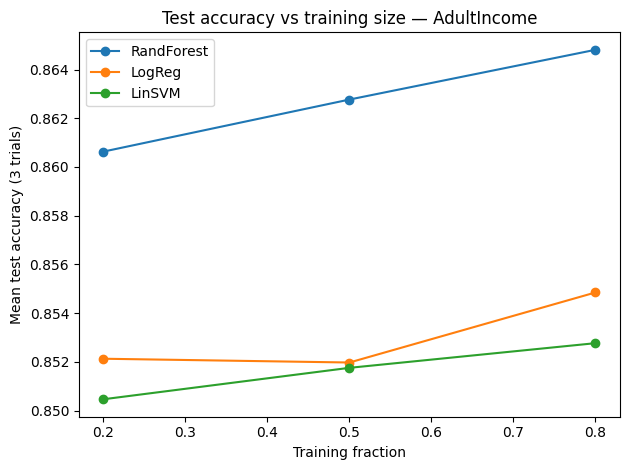

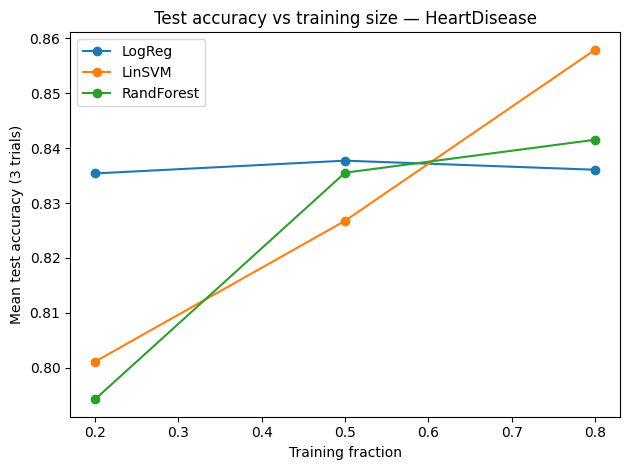

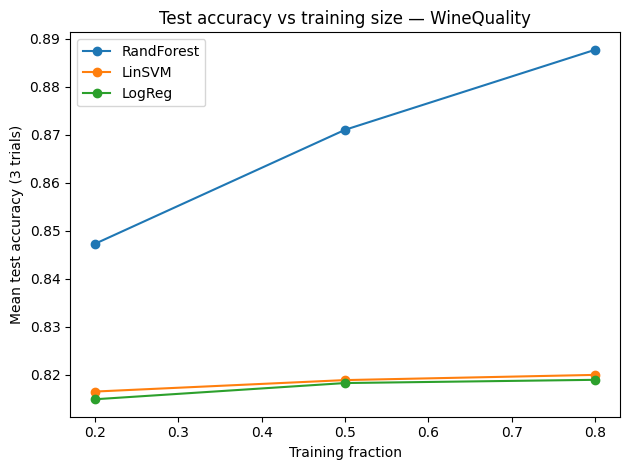

In [7]:
def plot_test_accuracy(summ: pd.DataFrame, out_dir: Path):
    out_dir.mkdir(parents=True, exist_ok=True)
    for dataset in summ["dataset"].unique():
        sub = summ[summ["dataset"] == dataset].copy()
        plt.figure()
        for clf in sub["classifier"].unique():
            s2 = sub[sub["classifier"] == clf].sort_values("train_frac")
            plt.plot(s2["train_frac"], s2["test_acc_mean"], marker="o", label=clf)
        plt.xlabel("Training fraction")
        plt.ylabel("Mean test accuracy (3 trials)")
        plt.title(f"Test accuracy vs training size — {dataset}")
        plt.legend()
        plt.tight_layout()
        plt.savefig(out_dir / f"{dataset}_test_accuracy_vs_trainfrac.png", dpi=200)
        plt.show()
        plt.close()

plot_test_accuracy(df_summary, OUT_DIR)


## 8) Export report tables

In [8]:
def make_table(summ: pd.DataFrame, train_frac: float) -> pd.DataFrame:
    sub = summ[summ["train_frac"] == train_frac].copy()
    sub["test_mean_std"] = sub.apply(
        lambda r: f"{r['test_acc_mean']:.3f} ± {0 if pd.isna(r['test_acc_std']) else r['test_acc_std']:.3f}", axis=1
    )
    table = sub.pivot(index="classifier", columns="dataset", values="test_mean_std")
    return table

for frac in TRAIN_FRACS:
    print(f"\n=== Test accuracy (mean ± std), train_frac={frac} ===")
    display(make_table(df_summary, frac))



=== Test accuracy (mean ± std), train_frac=0.2 ===


dataset,AdultIncome,HeartDisease,WineQuality
classifier,,,
LinSVM,0.850 ± 0.000,0.801 ± 0.031,0.817 ± 0.002
LogReg,0.852 ± 0.000,0.835 ± 0.007,0.815 ± 0.002
RandForest,0.861 ± 0.002,0.794 ± 0.008,0.847 ± 0.003



=== Test accuracy (mean ± std), train_frac=0.5 ===


dataset,AdultIncome,HeartDisease,WineQuality
classifier,,,
LinSVM,0.852 ± 0.002,0.827 ± 0.023,0.819 ± 0.003
LogReg,0.852 ± 0.002,0.838 ± 0.025,0.818 ± 0.001
RandForest,0.863 ± 0.002,0.836 ± 0.017,0.871 ± 0.004



=== Test accuracy (mean ± std), train_frac=0.8 ===


dataset,AdultIncome,HeartDisease,WineQuality
classifier,,,
LinSVM,0.853 ± 0.002,0.858 ± 0.034,0.820 ± 0.002
LogReg,0.855 ± 0.003,0.836 ± 0.028,0.819 ± 0.005
RandForest,0.865 ± 0.002,0.842 ± 0.050,0.888 ± 0.003


In [9]:
summary_lines = []
for name, (X, y) in datasets.items():
    summary_lines.append(
        f"{name}: n={len(y)}, d={X.shape[1]}, positive_rate={y.mean():.3f}\n"
    )

(OUT_DIR / "dataset_summary.txt").write_text("".join(summary_lines), encoding="utf-8")
print("Saved:", OUT_DIR / "dataset_summary.txt")
print("".join(summary_lines))

Saved: C:\Users\james\Desktop\Cogs118A\outputs\dataset_summary.txt
HeartDisease: n=303, d=13, positive_rate=0.459
WineQuality: n=6497, d=12, positive_rate=0.197
AdultIncome: n=48842, d=14, positive_rate=0.239

